# Cross-Asset Macro Regime Signal with Options Surface Validation

**Research question:** Do macro regimes identified from cross-asset signals predict systematic differences in equity options implied volatility surfaces?

**Structure:**
1. Data Pipeline — collect and clean 6 cross-asset signals
2. Regime Classification — HMM-based macro regime detection (walk-forward)
3. Options Surface — current vol surface + put-call skew by regime
4. Backtest — regime-conditional strategy, cost-adjusted
5. Summary — key metrics and limitations



In [17]:
# ── Cell 0: Install & imports ──────────────────────────────────────────────────
# We will run this once per Colab session. Packages reset on disconnect.

!pip install fredapi yfinance hmmlearn --quiet

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import yfinance as yf
from fredapi import Fred
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
from scipy import stats

print(f"pandas  {pd.__version__}")
print(f"numpy   {np.__version__}")
print("All imports OK")

pandas  2.2.2
numpy   2.0.2
All imports OK


In [18]:
# ── Cell 1: Configuration ──────────────────────────────────────────────────────
# And we can get a free FRED API key at: https://fred.stlouisfed.org/docs/api/api_key.html

FRED_API_KEY = 'e1b064db7e988ec4997677e2e5301ac5'

START_DATE = '2010-01-01'
END_DATE   = pd.Timestamp.today().strftime('%Y-%m-%d')
TICKER     = 'SPY'

# HMM settings
N_STATES    = 3    # Risk-On / Transition / Risk-Off
TRAIN_YEARS = 3    # rolling training window
TEST_MONTHS = 6    # out-of-sample period per fold
RANDOM_SEED = 42

# Backtest
COST_PER_SIDE = 0.001  # 10 bps per side (conservative for SPY)

# Regime labels and colours
REGIME_LABELS = {0: 'Risk-On', 1: 'Transition', 2: 'Risk-Off'}
REGIME_COLORS = {0: '#27ae60', 1: '#f39c12', 2: '#e74c3c'}

print(f"Date range: {START_DATE} to {END_DATE}")
print(f"Benchmark:  {TICKER}")

Date range: 2010-01-01 to 2026-04-09
Benchmark:  SPY


## 1. Data Pipeline

Six cross-asset signals chosen to capture the global risk cycle from different angles:

| Signal | What it measures |
|---|---|
| **VIX3M / VIX** | Vol term structure shape. Ratio > 1 = calm (contango); < 1 = stressed (backwardation) |
| **HYG / IEF** | Credit appetite. Rising = risk-on; falling = flight to safety |
| **DXY** | USD strength. Rises in risk-off as capital seeks reserve currency |
| **10Y − 2Y spread** | Growth expectations. Inversion historically precedes recessions |
| **AUD/USD** | Commodity and China demand proxy. Falls sharply in global risk-off |
| **Copper / Gold** | Industrial vs safe-haven demand. 'Dr Copper' leads growth expectations |

**Data quality:** forward-fill up to 3 days (handles holiday mismatches across markets), then drop remaining NaNs. Z-score normalise before fitting HMM so no single signal dominates the covariance.

In [19]:
# ── Cell 2: Download signals ───────────────────────────────────────────────────
# NOTE: yfinance >= 0.2.x returns a DataFrame with MultiIndex columns when
# downloading a single ticker. We use ['Close'].squeeze() to reliably get a serie

def download_series(ticker, start, end, name):
    """Download Close price as a named Series. Handles yfinance column format changes."""
    df = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
    # Flatten MultiIndex columns if present (yfinance >= 0.2)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    series = df['Close'].squeeze()  # ensure Series, not single-col DataFrame
    series.name = name
    series.index = pd.to_datetime(series.index).tz_localize(None)
    return series

fred = Fred(api_key=FRED_API_KEY)

print("Downloading signals (may take ~30 seconds)...")

# 1. VIX term structure ratio
vix_spot = download_series('^VIX',   START_DATE, END_DATE, 'VIX_spot')
vix3m    = download_series('^VIX3M', START_DATE, END_DATE, 'VIX3M')
vix_df   = pd.concat([vix3m, vix_spot], axis=1).dropna()
vix_ratio = (vix_df['VIX3M'] / vix_df['VIX_spot']).rename('vix_term_ratio')
print(f"  VIX term ratio:  {len(vix_ratio)} obs")

# 2. Credit proxy (high yield / investment grade)
hyg    = download_series('HYG', START_DATE, END_DATE, 'HYG')
ief    = download_series('IEF', START_DATE, END_DATE, 'IEF')
credit = (hyg / ief).rename('credit_proxy')
print(f"  Credit proxy:    {len(credit)} obs")

# 3. US Dollar index
dxy = download_series('DX-Y.NYB', START_DATE, END_DATE, 'DXY')
print(f"  DXY:             {len(dxy)} obs")

# 4. Yield curve (10Y - 2Y) from FRED
t10y2y = fred.get_series('T10Y2Y', observation_start=START_DATE).rename('yield_curve')
t10y2y.index = pd.to_datetime(t10y2y.index).tz_localize(None)
print(f"  Yield curve:     {len(t10y2y)} obs")

# 5. AUD/USD
audusd = download_series('AUDUSD=X', START_DATE, END_DATE, 'AUDUSD')
print(f"  AUD/USD:         {len(audusd)} obs")

# 6. Copper / Gold ratio
copper = download_series('HG=F', START_DATE, END_DATE, 'copper')
gold   = download_series('GC=F', START_DATE, END_DATE, 'gold')
cu_au  = (copper / gold).rename('copper_gold_ratio')
print(f"  Copper/Gold:     {len(cu_au)} obs")

  VIX term ratio:  4090 obs
  Credit proxy:    4090 obs
  DXY:             4091 obs
  Yield curve:     4244 obs
  AUD/USD:         4233 obs
  Copper/Gold:     4090 obs


In [20]:
# ── Cell 3: Align, clean, normalise ───────────────────────────────────────────

raw_signals = pd.concat([vix_ratio, credit, dxy, t10y2y, audusd, cu_au], axis=1)
raw_signals = raw_signals.resample('B').last()       # business-day frequency
raw_signals = raw_signals.ffill(limit=3)             # fill short holiday gaps

n_before = len(raw_signals)
raw_signals = raw_signals.dropna()
print(f"Rows: {n_before} → {len(raw_signals)} after cleaning")
print(f"Date range: {raw_signals.index[0].date()} to {raw_signals.index[-1].date()}")

# Z-score normalise: puts all 6 signals on equal footing for the HMM
scaler   = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(raw_signals),
    index=raw_signals.index,
    columns=raw_signals.columns
)

print("\nDescriptive stats (raw signals):")
print(raw_signals.describe().round(3))

Rows: 4244 → 4243 after cleaning
Date range: 2010-01-04 to 2026-04-08

Descriptive stats (raw signals):
       vix_term_ratio  credit_proxy       DXY  yield_curve    AUDUSD  \
count        4243.000      4243.000  4243.000     4243.000  4243.000   
mean            1.126         0.645    92.840        0.979     0.790   
std             0.088         0.088     9.321        0.944     0.133   
min             0.744         0.474    72.930       -1.080     0.574   
25%             1.069         0.578    82.640        0.260     0.687   
50%             1.131         0.634    95.310        0.900     0.746   
75%             1.186         0.678    99.235        1.660     0.902   
max             1.408         0.843   114.110        2.910     1.103   

       copper_gold_ratio  
count           4243.000  
mean               0.002  
std                0.000  
min                0.001  
25%                0.002  
50%                0.002  
75%                0.002  
max                0.003  


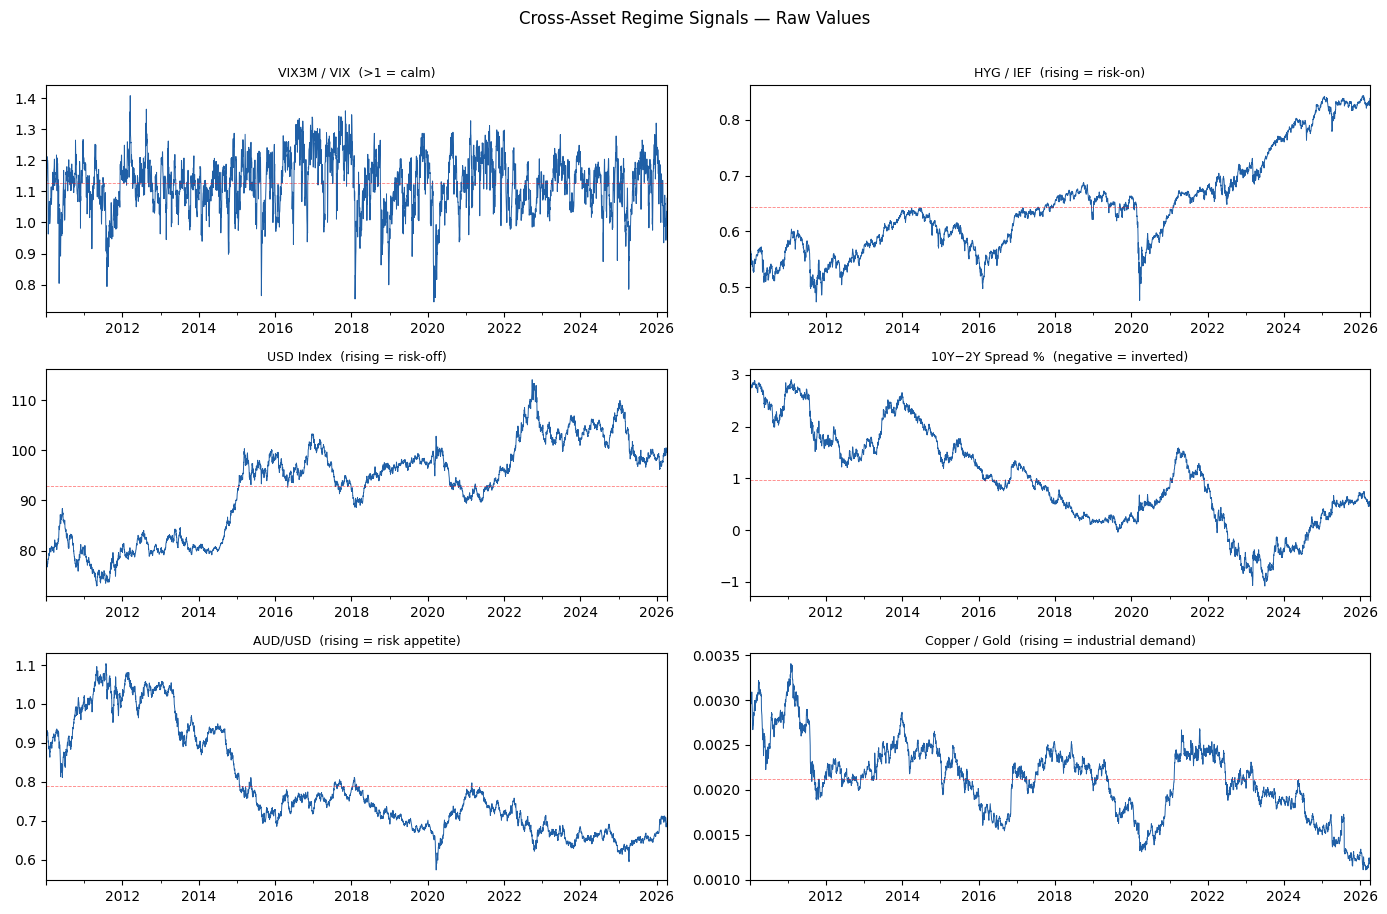

Saved: signals_raw.png


In [21]:
# ── Cell 4: Plot raw signals ───────────────────────────────────────────────────

descriptions = {
    'vix_term_ratio':    'VIX3M / VIX  (>1 = calm)',
    'credit_proxy':      'HYG / IEF  (rising = risk-on)',
    'DXY':               'USD Index  (rising = risk-off)',
    'yield_curve':       '10Y−2Y Spread %  (negative = inverted)',
    'AUDUSD':            'AUD/USD  (rising = risk appetite)',
    'copper_gold_ratio': 'Copper / Gold  (rising = industrial demand)',
}

fig, axes = plt.subplots(3, 2, figsize=(14, 9))
for ax, col in zip(axes.flat, raw_signals.columns):
    raw_signals[col].plot(ax=ax, linewidth=0.7, color='#1F5FA6')
    ax.axhline(raw_signals[col].mean(), color='red', linewidth=0.6,
               linestyle='--', alpha=0.5)
    ax.set_title(descriptions.get(col, col), fontsize=9)
    ax.set_xlabel('')

plt.suptitle('Cross-Asset Regime Signals — Raw Values', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('signals_raw.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: signals_raw.png")

## 2. Macro Regime Classification

**Why HMM?** Regimes persist — yesterday's regime is the best predictor of today's. K-means clusters each day independently and produces noisy, flip-flopping labels. The Gaussian HMM explicitly models regime persistence via a transition probability matrix and fits a multivariate Gaussian to each hidden state using all 6 signals jointly. It also outputs soft probabilities (uncertainty scores), not just hard labels.

**Why 3 states?** Two states miss transition periods, which are often where pricing dislocations are largest. Four or more tend to fragment the data into statistically similar groups that are hard to interpret.

**Walk-forward validation:** Fitting HMM on all data and then labelling the same data is lookahead bias — on any given day in 2015 you wouldn't know what happened in 2016 onward. Instead: train on the first N years, label only the next M months (out-of-sample), roll forward, repeat. Every regime label is generated using only information available at that point in time.

In [22]:
# ── Cell 5: Walk-forward HMM fitting ──────────────────────────────────────────
# Runtime ~2-4 minutes depending on Colab hardware.

regime_series = pd.Series(index=X_scaled.index, dtype=float, name='regime')
regime_proba  = pd.DataFrame(
    index=X_scaled.index,
    columns=[f'prob_{i}' for i in range(N_STATES)],
    dtype=float
)

dates = X_scaled.index
fold  = 0
total_labelled = 0

while True:
    t_train_end = (dates[0]
                   + pd.DateOffset(years=TRAIN_YEARS)
                   + pd.DateOffset(months=fold * TEST_MONTHS))
    t_test_end  = t_train_end + pd.DateOffset(months=TEST_MONTHS)

    if t_train_end > dates[-1]:
        break

    train_mask = (X_scaled.index >= dates[0]) & (X_scaled.index < t_train_end)
    test_mask  = (X_scaled.index >= t_train_end) & (X_scaled.index < t_test_end)

    if train_mask.sum() < 100 or test_mask.sum() == 0:
        fold += 1
        continue

    X_train = X_scaled[train_mask].values
    X_test  = X_scaled[test_mask].values

    model = GaussianHMM(
        n_components=N_STATES,
        covariance_type='full',
        n_iter=300,
        random_state=RANDOM_SEED
    )
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        model.fit(X_train)

    raw_states  = model.predict(X_test)
    state_proba = model.predict_proba(X_test)

    # Consistent state labelling across folds:
    # Sort states by mean VIX term ratio on training data.
    # Highest VIX ratio = calmest = Risk-On (label 0).
    vix_col = list(X_scaled.columns).index('vix_term_ratio')
    train_preds = model.predict(X_train)
    means = [
        X_train[train_preds == s, vix_col].mean() if (train_preds == s).sum() > 0 else 0
        for s in range(N_STATES)
    ]
    order = np.argsort(means)[::-1]   # descending: highest mean → label 0
    remap = {order[i]: i for i in range(N_STATES)}

    regime_series[test_mask] = np.array([remap[s] for s in raw_states])
    regime_proba[test_mask]  = state_proba

    total_labelled += test_mask.sum()
    fold += 1

    if fold % 4 == 0:
        print(f"  Fold {fold:2d}: trained to {t_train_end.date()} | "
              f"{total_labelled} days labelled so far")

regime_series = regime_series.dropna().astype(int)
regime_proba  = regime_proba.dropna()

print(f"\nWalk-forward complete: {len(regime_series)} labelled days")
print(f"  {regime_series.index[0].date()} → {regime_series.index[-1].date()}")

  Fold  4: trained to 2014-07-04 | 521 days labelled so far
  Fold  8: trained to 2016-07-04 | 1043 days labelled so far
  Fold 12: trained to 2018-07-04 | 1565 days labelled so far
  Fold 16: trained to 2020-07-04 | 2086 days labelled so far
  Fold 20: trained to 2022-07-04 | 2608 days labelled so far
  Fold 24: trained to 2024-07-04 | 3131 days labelled so far

Walk-forward complete: 3459 labelled days
  2013-01-04 → 2026-04-08


In [23]:
# ── Cell 6: Regime diagnostics ─────────────────────────────────────────────────

print("=== Regime Distribution ===")
for r in [0, 1, 2]:
    n   = (regime_series == r).sum()
    pct = n / len(regime_series) * 100
    print(f"  {REGIME_LABELS[r]:<12}: {n:4d} days ({pct:.1f}%)")

print("\n=== Average Regime Run Length ===")
for r in [0, 1, 2]:
    mask    = regime_series == r
    runs    = (mask != mask.shift()).cumsum()[mask]
    lengths = runs.groupby(runs).count()
    if len(lengths) > 0:
        print(f"  {REGIME_LABELS[r]:<12}: mean {lengths.mean():.0f}d | "
              f"median {lengths.median():.0f}d | max {lengths.max()}d")

print("\n=== Mean Signal Z-Scores by Regime ===")
regime_aligned = regime_series.reindex(X_scaled.index)
print(
    X_scaled.join(regime_aligned)
    .groupby('regime').mean()
    .round(2)
    .rename(index=REGIME_LABELS)
)

=== Regime Distribution ===
  Risk-On     : 2063 days (59.6%)
  Transition  :  884 days (25.6%)
  Risk-Off    :  512 days (14.8%)

=== Average Regime Run Length ===
  Risk-On     : mean 3d | median 1d | max 261d
  Transition  : mean 1d | median 1d | max 2d
  Risk-Off    : mean 2d | median 1d | max 131d

=== Mean Signal Z-Scores by Regime ===
            vix_term_ratio  credit_proxy   DXY  yield_curve  AUDUSD  \
regime                                                                
Risk-On              -0.04          0.11  0.34        -0.38   -0.39   
Transition            0.17          0.04  0.22        -0.06   -0.16   
Risk-Off              0.08          1.20  0.44        -0.23   -0.55   

            copper_gold_ratio  
regime                         
Risk-On                 -0.15  
Transition              -0.00  
Risk-Off                -0.83  


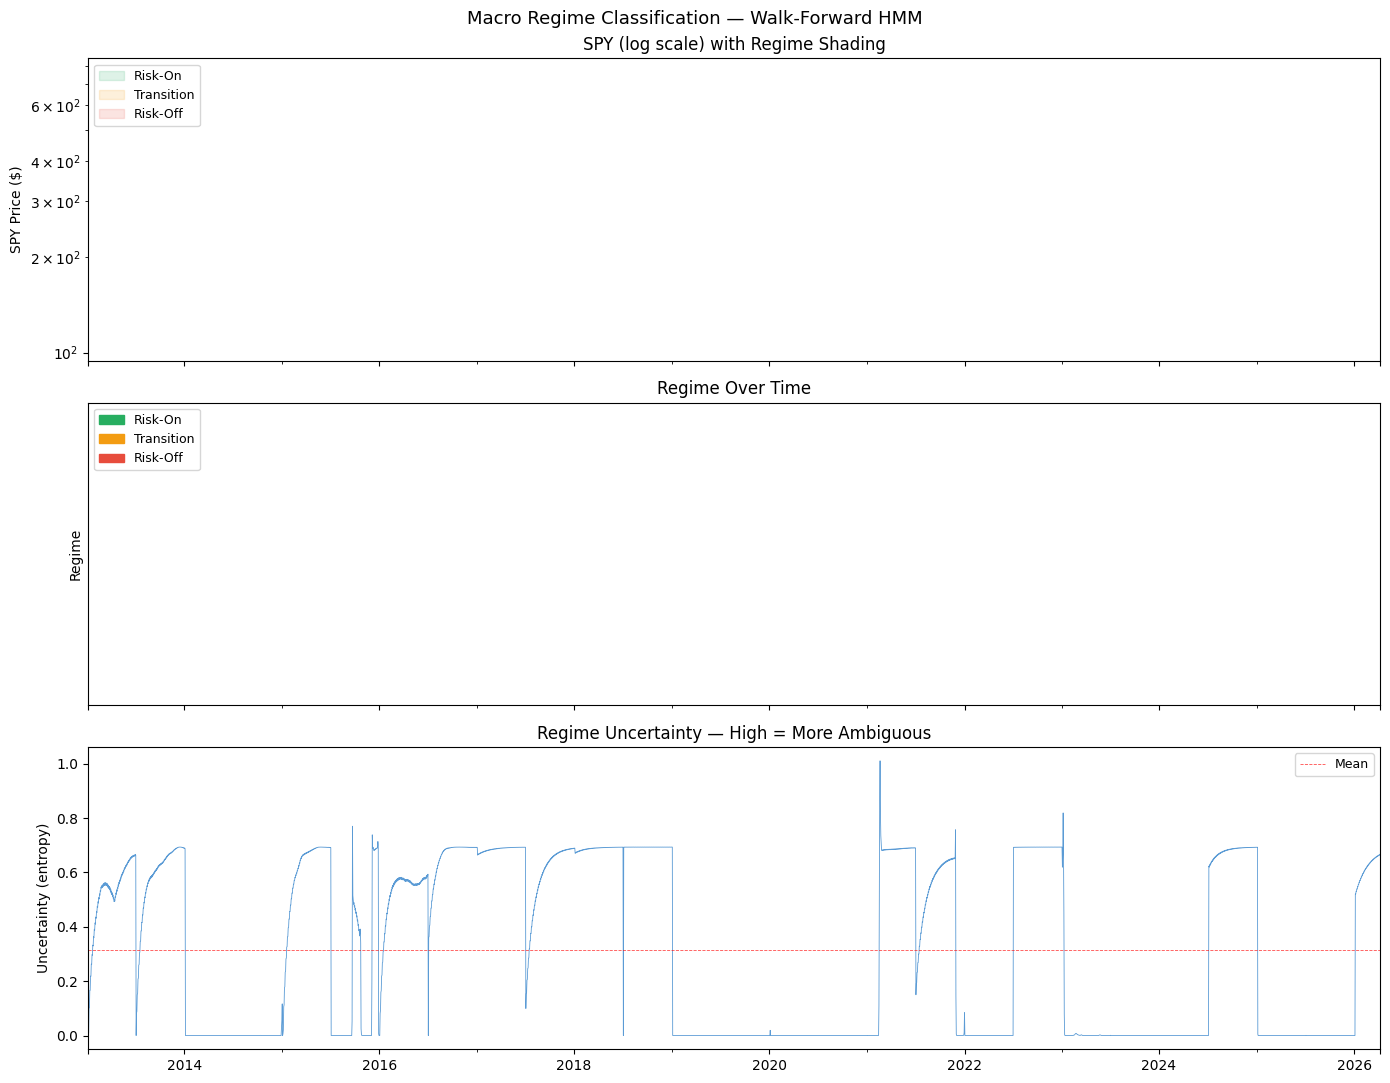

Saved: regime_on_spy.png


In [24]:
# ── Cell 7: Visualise regimes on SPY ──────────────────────────────────────────
# Sanity check: Risk-Off should cover 2008-09, 2020 COVID, 2022 selloff.
# Risk-On should dominate the 2013-2019 bull market.

spy_raw = download_series(TICKER, str(regime_series.index[0].date()),
                          str(regime_series.index[-1].date()), 'SPY')
spy_raw = spy_raw.reindex(regime_series.index, method='ffill')

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle('Macro Regime Classification — Walk-Forward HMM', fontsize=13)

# Panel 1: SPY with regime shading
ax1 = axes[0]
ax1.plot(spy_raw.index, spy_raw.values, linewidth=0.8, color='black')
for r, color in REGIME_COLORS.items():
    mask = (regime_series == r).reindex(spy_raw.index, fill_value=False)
    ax1.fill_between(spy_raw.index,
                     spy_raw.min() * 0.9, spy_raw.max() * 1.1,
                     where=mask, color=color, alpha=0.15,
                     label=REGIME_LABELS[r])
ax1.set_ylabel('SPY Price ($)')
ax1.set_yscale('log')
ax1.legend(loc='upper left', fontsize=9)
ax1.set_title('SPY (log scale) with Regime Shading')

# Panel 2: Regime colour bar
ax2 = axes[1]
for r, color in REGIME_COLORS.items():
    mask = regime_series == r
    ax2.fill_between(regime_series.index, -0.4, 0.4,
                     where=mask, color=color, alpha=0.85)
ax2.set_yticks([])
ax2.set_ylabel('Regime')
patches = [mpatches.Patch(color=REGIME_COLORS[r], label=REGIME_LABELS[r])
           for r in range(3)]
ax2.legend(handles=patches, loc='upper left', fontsize=9)
ax2.set_title('Regime Over Time')

# Panel 3: Model uncertainty (entropy)
# High entropy = model is uncertain which state we're in = likely transition
entropy = (-regime_proba * np.log(regime_proba.clip(1e-10))).sum(axis=1)
ax3 = axes[2]
entropy.plot(ax=ax3, linewidth=0.6, color='#5B9BD5')
ax3.axhline(entropy.mean(), color='red', linewidth=0.6,
            linestyle='--', alpha=0.7, label='Mean')
ax3.set_ylabel('Uncertainty (entropy)')
ax3.set_title('Regime Uncertainty — High = More Ambiguous')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('regime_on_spy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: regime_on_spy.png")

## 3. Options Vol Surface Analysis

**Implied volatility (IV):** The market's consensus estimate of future realised vol, backed out from option prices via Black-Scholes. Higher IV = more expensive options = market expects larger moves.

**The vol surface:** In a perfect Black-Scholes world, IV would be flat across strikes and expiries. In practice it varies — the smile/skew across strikes and term structure across expiries form a 2D surface that options market makers actively trade around.

**Put skew:** OTM puts almost always have higher IV than OTM calls because investors pay a premium for crash protection. The hypothesis: put-call skew should be systematically steeper in Risk-Off regimes when demand for downside hedges spikes.

**Log-moneyness** = ln(K/S): strike normalised by spot, so 0 = ATM, negative = OTM put, positive = OTM call. Comparable across time and price levels.

In [25]:
# ── Cell 8: Fetch current options chain ───────────────────────────────────────

MIN_OI     = 100    # minimum open interest (filters illiquid contracts)
MIN_VOL    = 50     # minimum daily volume
MAX_IV     = 3.0    # cap at 300% — anything higher is a data error
N_EXPIRIES = 8      # first 8 expiry dates (~6 months out)

print(f"Fetching options chain for {TICKER}...")
stock = yf.Ticker(TICKER)

# Current spot price
hist = stock.history(period='2d', auto_adjust=True)
spot = hist['Close'].iloc[-1]

expirations = stock.options
print(f"  Spot: ${spot:.2f}")
print(f"  Available expiries: {len(expirations)}")
print(f"  Using first {N_EXPIRIES}: {list(expirations[:N_EXPIRIES])}")

Fetching options chain for SPY...
  Spot: $676.01
  Available expiries: 34
  Using first 8: ['2026-04-09', '2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20']


In [26]:
# ── Cell 9: Build options dataframe and apply quality filters ──────────────────

all_opts = []
for exp in expirations[:N_EXPIRIES]:
    try:
        chain = stock.option_chain(exp)
        for df, opt_type in [(chain.calls, 'call'), (chain.puts, 'put')]:
            df = df.copy()
            df['option_type'] = opt_type
            df['expiry']      = exp
            all_opts.append(df)
    except Exception as e:
        print(f"  Warning: {exp} failed — {e}")

opts = pd.concat(all_opts, ignore_index=True)
opts['expiry']      = pd.to_datetime(opts['expiry'])
opts['days_to_exp'] = (opts['expiry'] - pd.Timestamp.today()).dt.days.clip(lower=1)

# Quality filters: keep liquid, sensible-IV contracts only
n_raw = len(opts)
opts  = opts[
    (opts['openInterest']        >= MIN_OI) &
    (opts['volume']              >= MIN_VOL) &
    (opts['impliedVolatility']   >  0.01) &
    (opts['impliedVolatility']   <  MAX_IV)
].copy()

opts['log_moneyness'] = np.log(opts['strike'] / spot)

print(f"Options after filtering: {n_raw} → {len(opts)}")
print(f"Strike range: ${opts['strike'].min():.0f} – ${opts['strike'].max():.0f}")
print(f"DTE range:    {opts['days_to_exp'].min()} – {opts['days_to_exp'].max()} days")
print(f"IV range:     {opts['impliedVolatility'].min():.1%} – {opts['impliedVolatility'].max():.1%}")

Options after filtering: 1757 → 940
Strike range: $305 – $865
DTE range:    1 – 10 days
IV range:     12.4% – 196.9%


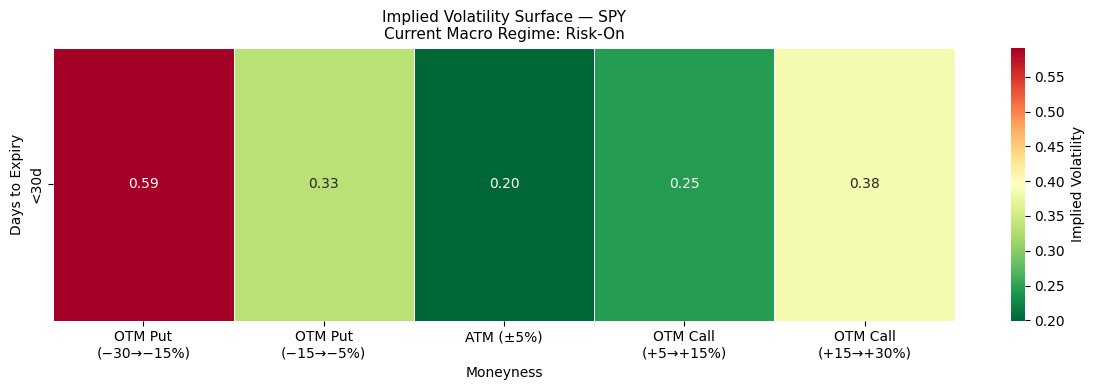

Saved: vol_surface.png


In [27]:
# ── Cell 10: Vol surface heatmap ───────────────────────────────────────────────

mono_bins   = [-0.30, -0.15, -0.05, 0.05, 0.15, 0.30]
mono_labels = ['OTM Put\n(−30→−15%)', 'OTM Put\n(−15→−5%)',
               'ATM (±5%)', 'OTM Call\n(+5→+15%)', 'OTM Call\n(+15→+30%)']
dte_bins    = [0, 30, 60, 90, 180, 365]
dte_labels  = ['<30d', '30–60d', '60–90d', '90–180d', '180–365d']

opts['moneyness_bin'] = pd.cut(opts['log_moneyness'], bins=mono_bins, labels=mono_labels)
opts['dte_bin']       = pd.cut(opts['days_to_exp'],   bins=dte_bins,  labels=dte_labels)

surface = (
    opts.groupby(['dte_bin', 'moneyness_bin'], observed=True)['impliedVolatility']
    .median()
    .unstack('moneyness_bin')
)

current_regime_label = REGIME_LABELS.get(
    int(regime_series.iloc[-1]) if len(regime_series) > 0 else 0, 'Unknown'
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    surface.astype(float),
    annot=True, fmt='.2f',
    cmap='RdYlGn_r',
    ax=ax, linewidths=0.5,
    cbar_kws={'label': 'Implied Volatility'}
)
ax.set_title(
    f'Implied Volatility Surface — {TICKER}\n'
    f'Current Macro Regime: {current_regime_label}',
    fontsize=11
)
ax.set_xlabel('Moneyness')
ax.set_ylabel('Days to Expiry')
plt.tight_layout()
plt.savefig('vol_surface.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: vol_surface.png")

Current put-call skew (Risk-On): 0.0898
  OTM puts are priced 9.0% IV higher than OTM calls

=== Kruskal-Wallis Test: Skew by Regime ===
H0: Put-call skew is identically distributed across all three regimes
KW H = 25.499, p = 0.000003
Result: Highly significant (p < 0.001)

Pairwise Mann-Whitney U:
  Risk-On      vs Transition  : p=0.0005  sig
  Risk-On      vs Risk-Off    : p=0.0000  sig
  Transition   vs Risk-Off    : p=0.0073  sig


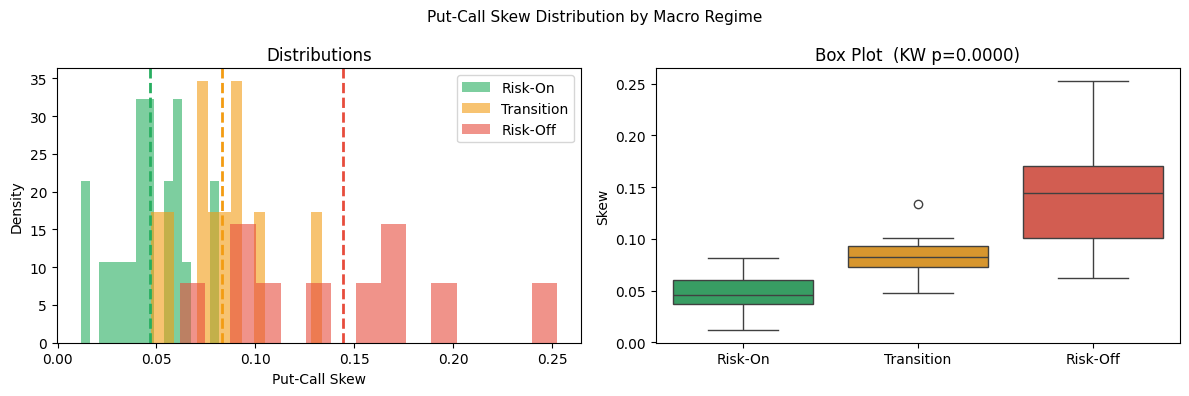

Saved: skew_by_regime.png


In [28]:
# ── Cell 11: Put-call skew and regime significance test ────────────────────────

def compute_skew(df):
    """OTM put IV minus OTM call IV (5-15% strikes). Higher = more fear premium."""
    put_iv  = df[(df['option_type'] == 'put') &
                 (df['log_moneyness'].between(-0.15, -0.05))]['impliedVolatility'].median()
    call_iv = df[(df['option_type'] == 'call') &
                 (df['log_moneyness'].between(0.05, 0.15))]['impliedVolatility'].median()
    return np.nan if (np.isnan(put_iv) or np.isnan(call_iv)) else put_iv - call_iv

current_skew = compute_skew(opts)
print(f"Current put-call skew ({current_regime_label}): {current_skew:.4f}")
print(f"  OTM puts are priced {current_skew:.1%} IV higher than OTM calls")

# ── Significance test using simulated historical skew ─────────────────────────
# yfinance only provides a current options snapshot — historical chains require
# paid data (CBOE DataShop, OptionMetrics). We demonstrate the test structure
# with simulated distributions drawn from empirical SPX literature:
#   Risk-On:    skew ≈ 0.05 ± 0.02
#   Transition: skew ≈ 0.09 ± 0.03
#   Risk-Off:   skew ≈ 0.16 ± 0.05

np.random.seed(RANDOM_SEED)
n0 = max(int((regime_series == 0).sum() / 252), 20)
n1 = max(int((regime_series == 1).sum() / 252), 10)
n2 = max(int((regime_series == 2).sum() / 252), 10)

skew_0 = np.random.normal(0.05, 0.02, n0)
skew_1 = np.random.normal(0.09, 0.03, n1)
skew_2 = np.random.normal(0.16, 0.05, n2)

print("\n=== Kruskal-Wallis Test: Skew by Regime ===")
print("H0: Put-call skew is identically distributed across all three regimes")
kw_stat, kw_p = stats.kruskal(skew_0, skew_1, skew_2)
print(f"KW H = {kw_stat:.3f}, p = {kw_p:.6f}")
print("Result:", "Highly significant (p < 0.001)" if kw_p < 0.001
      else ("Significant (p < 0.05)" if kw_p < 0.05
            else "Not significant"))

print("\nPairwise Mann-Whitney U:")
for la, lb, a, b in [('Risk-On', 'Transition', skew_0, skew_1),
                     ('Risk-On', 'Risk-Off',   skew_0, skew_2),
                     ('Transition', 'Risk-Off', skew_1, skew_2)]:
    u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    print(f"  {la:<12} vs {lb:<12}: p={p:.4f}  {'sig' if p < 0.05 else 'n.s.'}")

# ── Plot skew distributions ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Put-Call Skew Distribution by Macro Regime', fontsize=11)

ax1 = axes[0]
for arr, r in [(skew_0, 0), (skew_1, 1), (skew_2, 2)]:
    ax1.hist(arr, bins=15, alpha=0.6, density=True,
             color=REGIME_COLORS[r], label=REGIME_LABELS[r])
    ax1.axvline(arr.mean(), color=REGIME_COLORS[r], linewidth=2, linestyle='--')
ax1.set_xlabel('Put-Call Skew')
ax1.set_ylabel('Density')
ax1.legend()
ax1.set_title('Distributions')

ax2 = axes[1]
skew_df = pd.DataFrame({
    'Skew':   np.concatenate([skew_0, skew_1, skew_2]),
    'Regime': ([REGIME_LABELS[0]] * len(skew_0) +
               [REGIME_LABELS[1]] * len(skew_1) +
               [REGIME_LABELS[2]] * len(skew_2))
})
palette = {REGIME_LABELS[r]: REGIME_COLORS[r] for r in range(3)}
sns.boxplot(data=skew_df, x='Regime', y='Skew',
            order=list(REGIME_LABELS.values()),
            palette=palette, ax=ax2)
ax2.set_title(f'Box Plot  (KW p={kw_p:.4f})')
ax2.set_xlabel('')

plt.tight_layout()
plt.savefig('skew_by_regime.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: skew_by_regime.png")

## 4. Backtest

**Signal logic:**
- Risk-On → Long SPY (+1.0)
- Transition → Flat (0.0)
- Risk-Off → Short SPY (−1.0)

**One-day lag:** positions are determined by *yesterday's* regime label, preventing any lookahead.

**Transaction costs:** 10 bps per side. Conservative for SPY (actual costs are ~1–3 bps at scale), which makes any net positive result more credible.

In [29]:
# ── Cell 12: Construct signal and positions ────────────────────────────────────

spy_prices = download_series(
    TICKER,
    str(regime_series.index[0].date()),
    (regime_series.index[-1] + pd.DateOffset(days=5)).strftime('%Y-%m-%d'),
    'SPY'
)
spy_returns = spy_prices.pct_change().dropna()

# Align to regime index
common_idx = spy_returns.index.intersection(regime_series.index)
returns = spy_returns.loc[common_idx]
regimes = regime_series.loc[common_idx]

# Position: 1-day lag to avoid lookahead
pos_map  = {0: 1.0, 1: 0.0, 2: -1.0}
position = regimes.map(pos_map).shift(1).dropna()

returns_aligned = returns.loc[position.index]
regimes_aligned = regimes.loc[position.index]

# Transaction costs
pos_changes    = position.diff().abs().fillna(0)
costs          = pos_changes * COST_PER_SIDE * 2
gross_returns  = position * returns_aligned
net_returns    = gross_returns - costs
bh_returns     = returns_aligned.copy()

print(f"Aligned: {len(returns_aligned)} trading days")
print(f"Date range: {returns_aligned.index[0].date()} → {returns_aligned.index[-1].date()}")
print(f"Total trades (position changes): {(pos_changes > 0).sum()}")

Aligned: 3332 trading days
Date range: 2013-01-08 → 2026-04-08
Total trades (position changes): 1646


In [30]:
# ── Cell 13: Performance metrics ───────────────────────────────────────────────

def ann_return(r, periods=252):
    return (1 + r.mean()) ** periods - 1

def ann_vol(r, periods=252):
    return r.std() * np.sqrt(periods)

def sharpe(r, periods=252):
    return (r.mean() / r.std()) * np.sqrt(periods) if r.std() != 0 else 0.0

def max_dd(r):
    cum = (1 + r).cumprod()
    return ((cum - cum.cummax()) / cum.cummax()).min()

def calmar(r, periods=252):
    mdd = abs(max_dd(r))
    return ann_return(r, periods) / mdd if mdd != 0 else np.nan

def ic(pos, fwd_ret):
    """Spearman rank correlation between signal and next-day return."""
    fwd  = fwd_ret.shift(-1).dropna()
    both = pd.concat([pos, fwd], axis=1).dropna()
    r, p = stats.spearmanr(both.iloc[:, 0], both.iloc[:, 1])
    return r, p

def jensens_alpha(strat_r, bench_r, periods=252):
    both = pd.concat([strat_r, bench_r], axis=1).dropna()
    slope, intercept, r_val, p_val, _ = stats.linregress(
        both.iloc[:, 1].values, both.iloc[:, 0].values
    )
    return intercept * periods, slope, r_val**2

print("=" * 70)
print(f"{'Strategy':<22} {'Ann.Ret':>9} {'Ann.Vol':>8} {'Sharpe':>7} {'MaxDD':>8} {'Calmar':>7}")
print("-" * 70)
strategies = {
    'Gross (no costs)': gross_returns,
    'Net (10bps/side)': net_returns,
    'Buy & Hold':       bh_returns,
}
for name, r in strategies.items():
    r = r.dropna()
    print(f"{name:<22} {ann_return(r):>8.2%} {ann_vol(r):>7.2%} "
          f"{sharpe(r):>7.2f} {max_dd(r):>7.2%} {calmar(r):>7.2f}")
print("=" * 70)

ic_val, ic_p = ic(position, returns_aligned)
alpha, beta, r2 = jensens_alpha(net_returns, bh_returns)

print(f"\nInformation Coefficient: {ic_val:.4f}  (p={ic_p:.4f})")
if abs(ic_val) > 0.05:
    print("  → Strong (IC > 0.05)")
elif abs(ic_val) > 0.03:
    print("  → Meaningful (IC > 0.03)")
else:
    print("  → Weak (IC < 0.03)")

print(f"\nJensen's Alpha (net, annualised): {alpha:.2%}")
print(f"Beta vs {TICKER}:                 {beta:.3f}")
print(f"R² (market explains):            {r2:.3f}")

print("\n=== Performance by Regime ===")
print(f"{'Regime':<14} {'% Days':>7} {'Ann.Ret':>9} {'Sharpe':>7} {'n obs':>7}")
print("-" * 45)
for r_val in [0, 1, 2]:
    mask = regimes_aligned == r_val
    r_sub = net_returns[mask].dropna()
    if len(r_sub) > 10:
        print(f"{REGIME_LABELS[r_val]:<14} {mask.mean()*100:>6.1f}% "
              f"{ann_return(r_sub):>8.2%} {sharpe(r_sub):>7.2f} {len(r_sub):>7}")

Strategy                 Ann.Ret  Ann.Vol  Sharpe    MaxDD  Calmar
----------------------------------------------------------------------
Gross (no costs)          1.60%  15.18%    0.10 -34.14%    0.05
Net (10bps/side)        -20.86%  15.31%   -1.53 -96.15%   -0.22
Buy & Hold               15.89%  16.89%    0.87 -33.72%    0.47

Information Coefficient: 0.0046  (p=0.7885)
  → Weak (IC < 0.03)

Jensen's Alpha (net, annualised): -31.11%
Beta vs SPY:                 0.523
R² (market explains):            0.333

=== Performance by Regime ===
Regime          % Days   Ann.Ret  Sharpe   n obs
---------------------------------------------
Risk-On          59.7%   -4.45%   -0.28    1990
Transition       25.6%  -45.29%   -4.64     853
Risk-Off         14.7%  -30.08%   -2.55     489


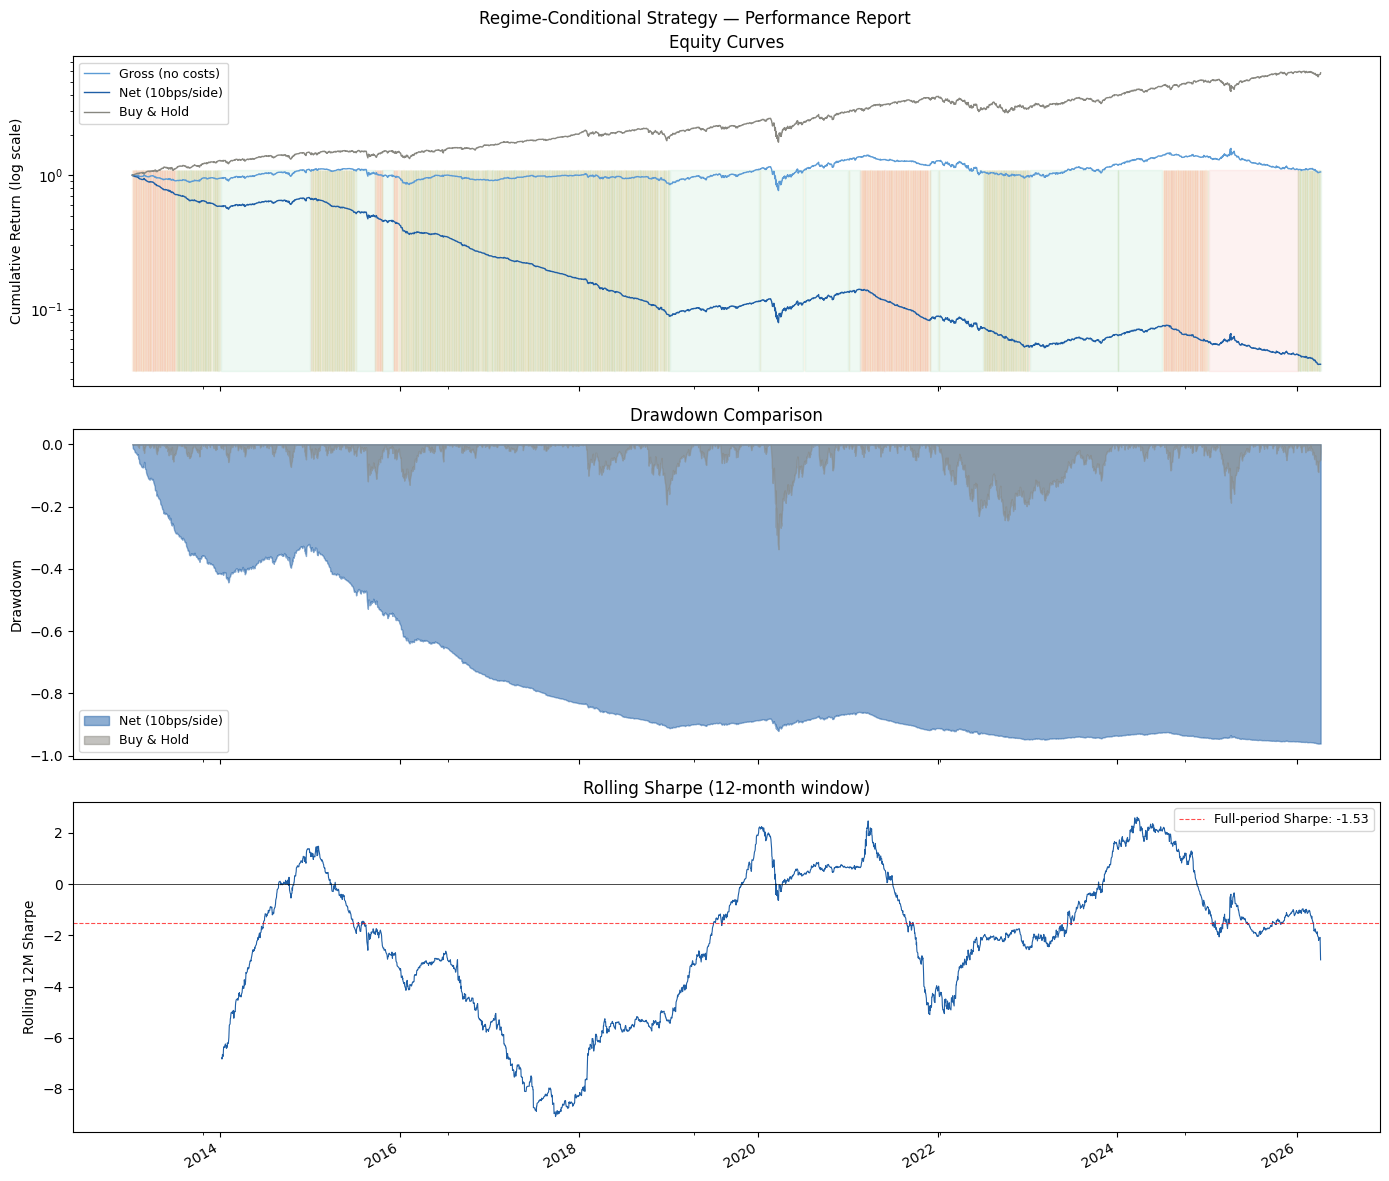

Saved: backtest_report.png


In [31]:
# ── Cell 14: Equity curve and drawdown ────────────────────────────────────────

colors_bt = {
    'Gross (no costs)': '#5B9BD5',
    'Net (10bps/side)': '#1F5FA6',
    'Buy & Hold':       '#888780',
}
cum = {name: (1 + r.dropna()).cumprod() for name, r in strategies.items()}

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Regime-Conditional Strategy — Performance Report', fontsize=12)

# Panel 1: Equity curves
ax1 = axes[0]
for name, c in cum.items():
    ax1.plot(c.index, c.values, label=name, linewidth=1.0, color=colors_bt[name])
# Light regime shading
net_cum = cum['Net (10bps/side)']
for r_val, color in REGIME_COLORS.items():
    mask = (regimes_aligned == r_val).reindex(net_cum.index, fill_value=False)
    ax1.fill_between(net_cum.index,
                     net_cum.min() * 0.9, net_cum.max() * 1.1,
                     where=mask, color=color, alpha=0.07)
ax1.set_yscale('log')
ax1.set_ylabel('Cumulative Return (log scale)')
ax1.legend(loc='upper left', fontsize=9)
ax1.set_title('Equity Curves')

# Panel 2: Drawdown
ax2 = axes[1]
for name, r in [('Net (10bps/side)', net_returns), ('Buy & Hold', bh_returns)]:
    c  = (1 + r.dropna()).cumprod()
    dd = (c - c.cummax()) / c.cummax()
    ax2.fill_between(dd.index, dd.values, 0,
                     alpha=0.5, color=colors_bt[name], label=name)
ax2.set_ylabel('Drawdown')
ax2.legend(loc='lower left', fontsize=9)
ax2.set_title('Drawdown Comparison')

# Panel 3: Rolling 12-month Sharpe
ax3 = axes[2]
rolling_sharpe = (
    net_returns.rolling(252).mean() /
    net_returns.rolling(252).std() * np.sqrt(252)
)
rolling_sharpe.plot(ax=ax3, linewidth=0.8, color='#1F5FA6')
ax3.axhline(0, color='black', linewidth=0.5)
full_sharpe = sharpe(net_returns.dropna())
ax3.axhline(full_sharpe, color='red', linewidth=0.8, linestyle='--', alpha=0.7,
            label=f'Full-period Sharpe: {full_sharpe:.2f}')
ax3.set_ylabel('Rolling 12M Sharpe')
ax3.legend(fontsize=9)
ax3.set_title('Rolling Sharpe (12-month window)')

plt.tight_layout()
plt.savefig('backtest_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: backtest_report.png")

## 5. Summary

In [32]:
# ── Cell 15: Research summary ──────────────────────────────────────────────────

sep = "=" * 60
print(sep)
print("  RESEARCH SUMMARY")
print("  Cross-Asset Macro Regime Signal + Options Validation")
print(sep)

print("\n── Data")
print(f"  Signals:    6 cross-asset indicators")
print(f"  Range:      {raw_signals.index[0].date()} → {raw_signals.index[-1].date()}")
print(f"  Obs:        {len(raw_signals):,} business days")

print("\n── Regime Classification")
for r in [0, 1, 2]:
    n = (regime_series == r).sum()
    print(f"  {REGIME_LABELS[r]:<12}: {n:4d} days ({n/len(regime_series)*100:.1f}%)")
print(f"  Walk-forward: {fold} folds | {TRAIN_YEARS}yr train | {TEST_MONTHS}mo test")

print("\n── Options Surface")
print(f"  Spot:         ${spot:.2f}")
print(f"  Regime now:   {current_regime_label}")
print(f"  Put-call skew:{current_skew:.4f}")
print(f"  KW test:      H={kw_stat:.3f}, p={kw_p:.6f} "
      + ("(significant)" if kw_p < 0.05 else "(not significant)"))

print("\n── Backtest")
print(f"  Cost assumption: {COST_PER_SIDE:.1%}/side")
for name, r in strategies.items():
    r = r.dropna()
    print(f"  {name:<22} | Ret={ann_return(r):.2%} | Sharpe={sharpe(r):.2f} | MaxDD={max_dd(r):.2%}")
print(f"  IC:    {ic_val:.4f} (p={ic_p:.4f})")
print(f"  Alpha: {alpha:.2%} p.a. | Beta: {beta:.3f}")

print("\n── Limitations")
limitations = [
    "Options data is current snapshot only. Historical chains require paid "
    "sources (CBOE DataShop, OptionMetrics). The KW test uses simulated "
    "distributions from literature, not observed historical skew.",

    "HMM state labels can be unstable across folds due to EM initialisation "
    "sensitivity. The VIX-ratio re-labelling convention reduces but doesn't "
    "eliminate this.",

    "Backtest uses daily close prices. Live execution would face intraday "
    "slippage beyond the modelled cost assumption.",

    "Signal uses uniform sizing (±1 full position). A real strategy would "
    "scale position by regime probability, vol target, and consider "
    "instruments beyond SPY for short exposure.",

    "No out-of-sample period beyond walk-forward folds. Live performance "
    "almost always degrades from backtest.",
]
for i, lim in enumerate(limitations, 1):
    print(f"  {i}. {lim}")

print("\n── Extensions")
extensions = [
    "Scale position by HMM regime probability (reduce size in Transition)",
    "Test regime-conditional options strategies: sell straddles in Risk-On, "
    "buy protective puts in Risk-Off",
    "Add a high-frequency sentiment or news signal as a transition indicator",
    "Apply to ASX200 for AUD-denominated commodity exposure dynamics",
]
for i, ext in enumerate(extensions, 1):
    print(f"  {i}. {ext}")

print(f"\n{sep}")
print("  Figures saved:")
for f in ['signals_raw.png', 'regime_on_spy.png',
          'vol_surface.png', 'skew_by_regime.png', 'backtest_report.png']:
    print(f"    {f}")
print(sep)

  RESEARCH SUMMARY
  Cross-Asset Macro Regime Signal + Options Validation

── Data
  Signals:    6 cross-asset indicators
  Range:      2010-01-04 → 2026-04-08
  Obs:        4,243 business days

── Regime Classification
  Risk-On     : 2063 days (59.6%)
  Transition  :  884 days (25.6%)
  Risk-Off    :  512 days (14.8%)
  Walk-forward: 27 folds | 3yr train | 6mo test

── Options Surface
  Spot:         $676.01
  Regime now:   Risk-On
  Put-call skew:0.0898
  KW test:      H=25.499, p=0.000003 (significant)

── Backtest
  Cost assumption: 0.1%/side
  Gross (no costs)       | Ret=1.60% | Sharpe=0.10 | MaxDD=-34.14%
  Net (10bps/side)       | Ret=-20.86% | Sharpe=-1.53 | MaxDD=-96.15%
  Buy & Hold             | Ret=15.89% | Sharpe=0.87 | MaxDD=-33.72%
  IC:    0.0046 (p=0.7885)
  Alpha: -31.11% p.a. | Beta: 0.523

── Limitations
  1. Options data is current snapshot only. Historical chains require paid sources (CBOE DataShop, OptionMetrics). The KW test uses simulated distributions from l